### Feature Engineering (Construction and Splitting). This is where domain knowledge and human intuition beat raw algorithms.

Feature Construction: Combining two or more existing columns to create a brand new, highly predictive column.

Feature Splitting: Taking one messy, complex column and breaking it into multiple clean columns.



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# loading raw titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Columns available:", df.columns.tolist())

Columns available: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


# Feature Transformation:

In [4]:
# Feature construction math and logic
# i am combining sibsp + parch to create a new family size feature
# +1 because i am counting that person also in the family
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1


In [6]:
# Now we can make a new feature if a guy is travelling alone or not then we can
# check that he survived or not
df['Is_Alone'] = np.where(df['Family_Size'] == 1, 1, 0)

df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Is_Alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1


In [7]:
# # Concept: The 'Fare' was for the whole ticket, not per person.
# Let's construct a true economic indicator.
df['Fare_Per_Person'] = df['Fare'] / df['Family_Size']

print("\n--- Constructed Features ---")
display(df[['SibSp', 'Parch', 'Family_Size', 'Is_Alone', 'Fare', 'Fare_Per_Person']].head())


--- Constructed Features ---


,SibSp,Parch,Family_Size,Is_Alone,Fare,Fare_Per_Person
0,1,0,2,0,7.2500,3.62500
1,1,0,2,0,71.2833,35.64165
2,0,0,1,1,7.9250,7.92500
3,1,0,2,0,53.1000,26.55000
4,0,0,1,1,8.0500,8.05000


# Feature Splitting

In [14]:
# We can see the name column (e.g "Branund, Mr. Owen Harris")
# It contains a title (Mr. miss. master etc) a title which tellus gender age, etc
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+).', expand=False)
print(df['Title'].tail(7))
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Countess', 'Sir', 'Jonkheer', 'Lady', 'Capt', 'Don']

df['Title'] = df['Title'].replace(rare_titles, 'Misc')

# Fix some common French misspellings
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print("\n--- Split Features ---")
display(df[['Name', 'Title']].tail(7))

884      Mr
885     Mrs
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, dtype: object

--- Split Features ---


,Name,Title
884,"Sutehall, Mr. Henry Jr",Mr
885,"Rice, Mrs. William (Margaret Norton)",Mrs
886,"Montvila, Rev. Juozas",Misc
887,"Graham, Miss. Margaret Edith",Miss
888,"Johnston, Miss. Catherine Helen ""Carrie""",Miss
889,"Behr, Mr. Karl Howell",Mr
890,"Dooley, Mr. Patrick",Mr


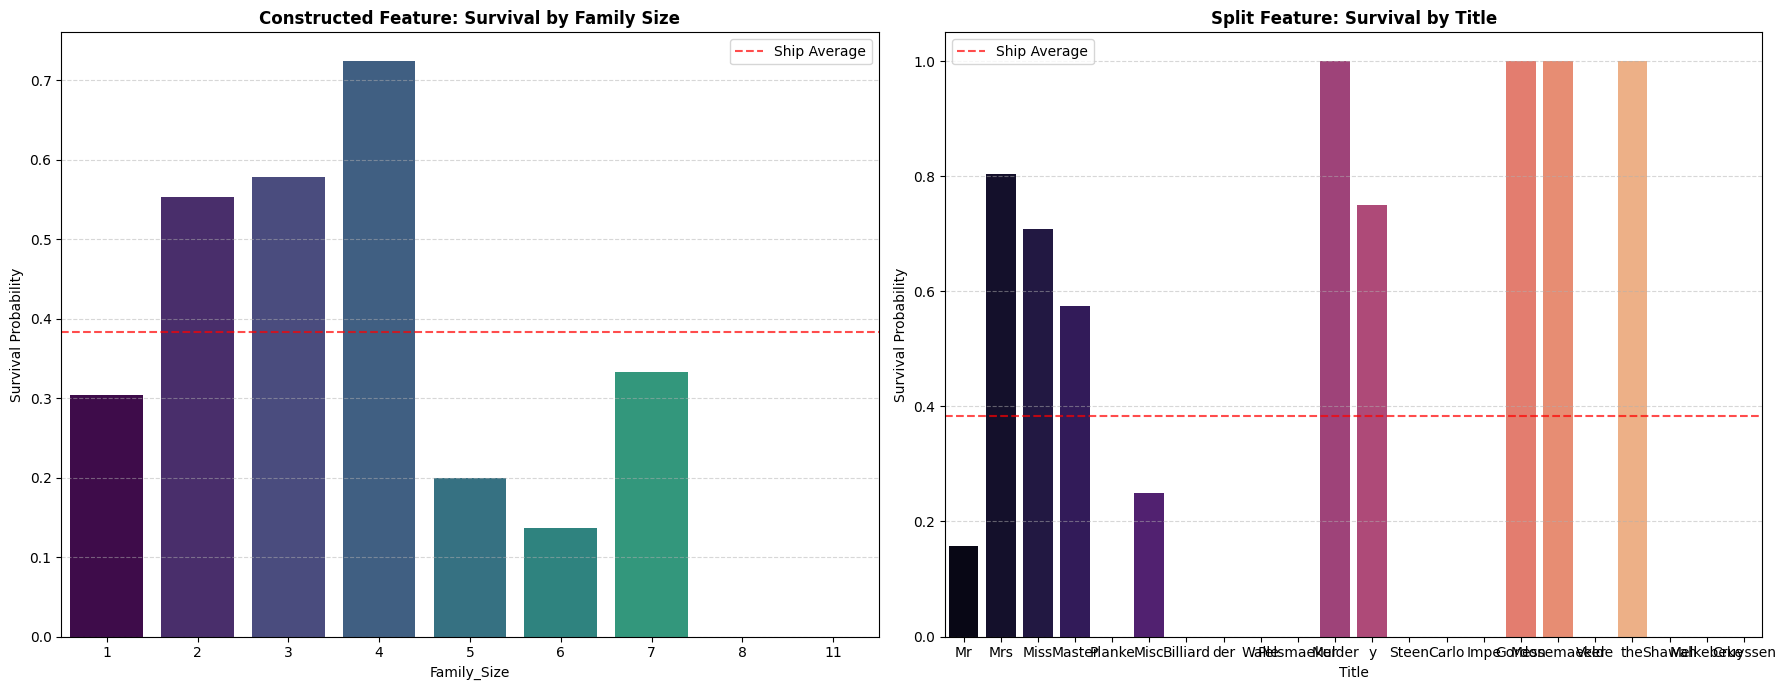

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization
# Did all this work actually help us predict who survived? Let's graph it!
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # Increased figure size for better display

# Plot 1: Survival by Constructed Feature (Family Size)
sns.barplot(x='Family_Size', y='Survived', data=df, ax=axes[0], palette='viridis', errorbar=None, hue='Family_Size', legend=False)
axes[0].set_title('Constructed Feature: Survival by Family Size', fontweight='bold')
axes[0].set_ylabel('Survival Probability')
axes[0].axhline(df['Survived'].mean(), color='red', linestyle='--', alpha=0.7, label='Ship Average') # Increased alpha for better visibility
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5) # Added grid

# Plot 2: Survival by Split Feature (Title)
sns.barplot(x='Title', y='Survived', data=df, ax=axes[1], palette='magma', errorbar=None, hue='Title', legend=False)
axes[1].set_title('Split Feature: Survival by Title', fontweight='bold')
axes[1].set_ylabel('Survival Probability')
axes[1].axhline(df['Survived'].mean(), color='red', linestyle='--', alpha=0.7, label='Ship Average') # Increased alpha for better visibility
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5) # Added grid

plt.tight_layout()
plt.show()

# What you should notice when you run this:
1. The Constructed Plot (Family Size):
Look at the green/blue bars. If you are Is_Alone (Family Size = 1), your survival was terrible (below the red average line). If you had a family size of 2, 3, or 4, your survival probability skyrocketed! But if your family was too big (5+), survival plummeted again (likely because it was too hard to keep everyone together during the sinking). By constructing this feature, you just handed your machine learning model a massive clue it wouldn't have easily figured out on its own.

2. The Split Plot (Title):
Look at the Name column. A raw model would just delete it. But by splitting it to find the Title, look at the graph!

- Mr. has a horrific survival rate.

- Mrs. and Miss. have phenomenal survival rates.

- Master. (which was the title used for young male children back then) has a much higher survival rate than "Mr.". If we just looked at the Sex column (Male/Female), the model would assume all males died. By splitting the text, we saved the little boys!